![图片描述](rnn.jpg)

### Formula 1: Hidden Layer Linear Combination

$$a_t = W_x x_t + W_h h_{t-1} + b_h$$

This is the **"linear part"** of the RNN at step $t$.

In [2]:
import numpy as np

Wx = np.array([[0.5]])
Wh = np.array([[0.8]])
bh = np.array([[0.1]])

x_t = np.array([[2.0]])      # 当前输入
h_prev = np.array([[0.3]])   # 上一步隐藏状态

a_t = Wx @ x_t + Wh @ h_prev + bh
print(a_t)

[[1.34]]


$$a_t = 0.5 \times 2.0 + 0.8 \times 0.3 + 0.1= 1.34$$

The **tanh function** (hyperbolic tangent function) is primarily used as an **activation function** in machine learning. It is a classic non-linear transformation function within neural networks.

$$tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

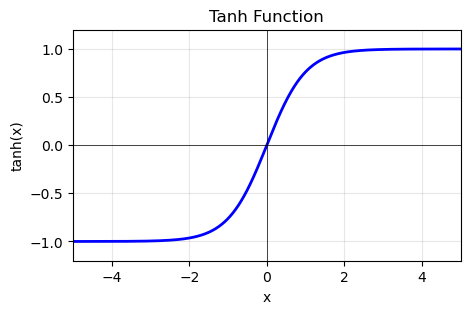

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 定义x范围
x = np.linspace(-5, 5, 1000)

# 计算tanh值
y = np.tanh(x)

# 绘图
plt.figure(figsize=(5, 3))
plt.plot(x, y, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.title('Tanh Function')
plt.ylim(-1.2, 1.2)
plt.xlim(-5, 5)

# 显示图形
plt.show()

### 3. Formula 2: Hidden State Update

**Mathematical Formula:**

$$h_t = \tanh(a_t)$$

**It can also be written as:**

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h)$$

In [2]:
a_t = np.array([[1.34]])
h_t = np.tanh(a_t)
print(h_t)

[[0.87167225]]


### Formula 3: Output Layer Calculation

$$y_t = W_y h_t + b_y$$

In [4]:
Wy = np.array([[1.2]])
by = np.array([[0.2]])
h_t = np.array([[0.87167225]])

y_t = Wy @ h_t + by
print(y_t)

[[1.2460067]]


$$y_t = 1.2 \times 0.87167225 + 0.2 = 1.2460067$$

### Formula 4: Single-Step Loss Function

$$L_t = \frac{1}{2}(y_t - t_t)^2$$

In [5]:
y_t = np.array([[1.246]])
target_t = np.array([[2.0]])

L_t = 0.5 * np.sum((y_t - target_t) ** 2)
print(L_t)

0.284258


### Formula 5: Total Sequence Loss

$$L = \sum_{t=1}^{T} L_t$$

**Or in Average form:**

$$L = \frac{1}{T} \sum_{t=1}^{T} L_t$$

In [7]:
losses = [0.1, 0.2, 0.3, 0.4]
total_loss = sum(losses)
avg_loss = total_loss / len(losses)

print("总损失:", total_loss)
print("平均损失:", avg_loss)

总损失: 1.0
平均损失: 0.25


### Formula 6: Output Layer Gradient

**Mathematical Formula:**

$$L_t = \frac{1}{2}(y_t - t_t)^2$$

$$\frac{d}{dy} \frac{1}{2}(y - t)^2 = y - t$$

$$\frac{\partial L_t}{\partial y_t} = y_t - t_t$$

**Notation:**

$$dy_t = y_t - t_t$$

In [9]:
y_t = np.array([[1.246]])
target_t = np.array([[2.0]])

dy = y_t - target_t
print(dy)

[[-0.754]]


### Formula 7: Output Layer Parameter Gradient $dW_y$

$$\frac{\partial L}{\partial W_y} = \sum_{t} dy_t h_t^T$$

In [10]:
dy = np.array([[-0.754]])             # shape (1,1)
h_t = np.array([[0.87], [0.20]])      # shape (2,1)

dWy = dy @ h_t.T
print(dWy)

[[-0.65598 -0.1508 ]]


### Formula 8: Output Layer Bias Gradient $db_y$

**Mathematical Formula:**

$$\frac{\partial L}{\partial b_y} = \sum_{t} dy_t$$

In [13]:
dy1 = np.array([[0.2]])
dy2 = np.array([[-0.1]])
dy3 = np.array([[0.3]])

dby = dy1 + dy2 + dy3
print(dby)

[[0.4]]


### Why don't we need to multiply by anything else?

**Because:**
$$y_t = W_y h_t + b_y$$

**Taking the derivative with respect to $b_y$:**
$$\frac{\partial y_t}{\partial b_y} = 1$$

**Therefore, the gradient is simply $dy$.**

### Formula 9: Total Gradient of the Hidden Layer $dh$



**According to the Chain Rule:**
$$\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial y_t} \cdot \frac{\partial y_t}{\partial h_t} + \frac{\partial L}{\partial h_{t+1}} \cdot \frac{\partial h_{t+1}}{\partial h_t}$$

**Mathematical Formula:**
$$dh_t = W_y^T dy_t + dh_{next}$$

**A more complete understanding:**

$$dh_t = \text{Gradient passed back from the current output} + \text{Gradient passed back from future time steps}$$

In [14]:
Wy = np.array([[1.2, -0.5]])     # shape (1,2)
dy = np.array([[-0.754]])        # shape (1,1)
dh_next = np.array([[0.1], [0.2]])

dh = Wy.T @ dy + dh_next
print(dh)

[[-0.8048]
 [ 0.577 ]]



$$W_y^T dy = \begin{bmatrix} 1.2 \\ -0.5 \end{bmatrix} (-0.754) = \begin{bmatrix} -0.9048 \\ 0.377 \end{bmatrix}$$

$$dh = \begin{bmatrix} -0.9048 \\ 0.377 \end{bmatrix} + \begin{bmatrix} 0.1 \\ 0.2 \end{bmatrix} = \begin{bmatrix} -0.8048 \\ 0.577 \end{bmatrix}$$

### Why must we add `dh_next`?

This is exactly where RNNs differ most from standard neural networks.

**Because, across time:**

$$h_t \rightarrow h_{t+1} \rightarrow h_{t+2}$$

Therefore, errors from the future will inevitably propagate back. If you do not add `dh_next`, it is equivalent to ignoring the "memory chain," and it would not be a complete BPTT (Backpropagation Through Time).

### Formula 10: Gradient of Pre-activation Variable `da`

**Mathematical Formula:**

$$da_t = dh_t \odot (1 - h_t^2)$$

**Because:**

$$h_t = \tanh(a_t)$$

**And:**

$$\frac{d \tanh(a_t)}{da_t} = 1 - h_t^2$$

In [16]:
dh = np.array([[0.8], [-0.3]])
h_t = np.array([[0.6], [0.2]])

da = dh * (1 - h_t ** 2)
print(da)

[[ 0.512]
 [-0.288]]


第一维：0.8 * (1 - 0.36) = 0.8 * 0.64 = 0.512

第二维：-0.3 * (1 - 0.04) = -0.3 * 0.96 = -0.288

### Chain Rule and Gradient Vanishing

**This step is the Chain Rule:**

$$\frac{\partial L}{\partial a_t} = \frac{\partial L}{\partial h_t} \cdot \frac{\partial h_t}{\partial a_t}$$

**Why is Gradient Vanishing likely to occur here?**

Because the derivative of $tanh$ is:

$$1 - h_t^2$$

### Formula 11: Input Weight Gradient `dWx`

**Mathematical Formula:**

$$\frac{\partial L}{\partial W_x} = \sum_{t} da_t x_t^T$$

In [17]:
da = np.array([[0.5], [-0.2]])   # shape (2,1)
x_t = np.array([[3.0]])          # shape (1,1)

dWx = da @ x_t.T
print(dWx)

[[ 1.5]
 [-0.6]]


### Formula 12: Recurrent Weight Gradient `dWh`

**Mathematical Formula:**

$$\frac{\partial L}{\partial W_h} = \sum_{t} da_t h_{t-1}^T$$

In [18]:
da = np.array([[0.5], [-0.2]])             # shape (2,1)
h_prev = np.array([[0.1], [0.4]])          # shape (2,1)

dWh = da @ h_prev.T
print(dWh)

[[ 0.05  0.2 ]
 [-0.02 -0.08]]


### Formula 13: Hidden Layer Bias Gradient `dbh`

**Mathematical Formula:**

$$\frac{\partial L}{\partial b_h} = \sum_{t} da_t$$

In [3]:
da1 = np.array([[0.2], [0.1]])
da2 = np.array([[-0.3], [0.4]])

dbh = da1 + da2
print(dbh)

[[-0.1]
 [ 0.5]]


### Formula 14: Gradient Passed to the Previous Time Step `dh_next`

**Mathematical Formula:**

$$dh_{t-1}^{(future)} = W_h^T da_t$$

**Written in code as:**

$$dh_{next} = W_h^T da$$

In [4]:
Wh = np.array([[0.5, 0.2],
               [0.1, 0.7]])

da = np.array([[0.4],
               [-0.3]])

dh_next = Wh.T @ da
print(dh_next)

[[ 0.17]
 [-0.13]]
